In [2]:
from langgraph.graph import StateGraph, START, END
import random
from typing import TypedDict

In [ ]:
class AgentState(TypedDict):
    player_name: str
    guesses: list[int]
    attemps: int
    lower_bound: int
    upper_bound: int
    bound: int


def setup(state: AgentState) -> AgentState:
    state["attemps"] = 0
    state["bound"] = random.randint(state["lower_bound"], state["upper_bound"])
    print(f"bound is {state["bound"]}")
    return state


def guess(state: AgentState) -> AgentState:
    state["attemps"] = state["attemps"] + 1
    current = random.randint(state["lower_bound"], state["upper_bound"])
    print(f"attemps: {state['attemps']}, current: {current}")
    state["guesses"].append(current)
    return state


def hint(state: AgentState) -> AgentState:
    if state["guesses"][-1] > state["bound"]:
        state["upper_bound"] = state["guesses"][-1] - 1
    else:
        state["lower_bound"] = state["guesses"][-1] + 1
    return state


def check(state: AgentState) -> str:
    if state["guesses"][-1] == state["bound"] or state["attemps"] >= 7:
        return "break"
    else:
        return "continue"


graph = StateGraph(AgentState)

graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("hint", hint)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")
graph.add_conditional_edges("hint", check, {"break": END, "continue": "guess"})


app = graph.compile()

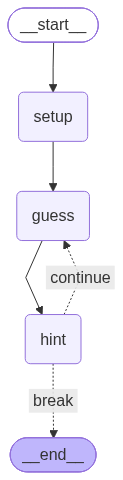

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
input = AgentState(
    player_name="Student", guesses=[], attemps=0, lower_bound=1, upper_bound=20
)
app.invoke(input)

bound is 18
attemps: 1, current: 7
attemps: 2, current: 8
attemps: 3, current: 10
attemps: 4, current: 13
attemps: 5, current: 15
attemps: 6, current: 20
attemps: 7, current: 16


{'player_name': 'Student',
 'guesses': [7, 8, 10, 13, 15, 20, 16],
 'attemps': 7,
 'lower_bound': 17,
 'upper_bound': 19,
 'bound': 18}